# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W28 | **Analysis Date:** 2026-07-06


## 1. Introducción

Esta semana, nos sumergimos en un océano de 100 canciones que han conquistado 22 países con 16 géneros distintos, acumulando más de 1.2 mil millones de vistas y 251 millones de likes. Con un promedio de 12.8 millones de visualizaciones por tema, los datos revelan un ecosistema vibrante donde cada clic cuenta una historia. ¿Qué tendencias emergen por región? ¿Qué géneros generan mayor engagement? ¿Cómo brillan las colaboraciones entre artistas? Este informe desmenuza el pulso global de YouTube, desde los hits que cruzan fronteras hasta las sorpresas que dictan las listas. Prepárate para descubrir patrones inesperados y entender qué mueve realmente a la audiencia. Los números hablan, y esta semana tienen mucho que decir.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W28_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W28_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,6,68569178,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-07-06 16:48:13,2,6.88
1,2,288,Oliver Tree,Life Goes On,15,61723300,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-07-06 16:48:13,2,15.51
2,3,289,Oliver Tree & Robin Schulz,Miss You,20,34621788,https://www.youtube.com/watch?v=BX0lKSa_PTk,170,2:50,2022-10-27,...,1,2,0,United States,Alternative,2/2,,2026-07-06 16:48:14,4,13.96
3,4,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,53,32445892,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-07-06 16:48:14,2,22.18
4,5,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,54,29682539,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-07-06 16:48:14,2,87.41


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,6,68569178,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-07-06 16:48:13,2,6.88
1,2,288,Oliver Tree,Life Goes On,15,61723300,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-07-06 16:48:13,2,15.51
2,3,289,Oliver Tree & Robin Schulz,Miss You,20,34621788,https://www.youtube.com/watch?v=BX0lKSa_PTk,170,2:50,2022-10-27,...,1,2,0,United States,Alternative,2/2,,2026-07-06 16:48:14,4,13.96
3,4,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,53,32445892,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-07-06 16:48:14,2,22.18
4,5,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,54,29682539,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-07-06 16:48:14,2,87.41


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [22],
    'Unique Genres': [16],
    'Total Views': [1282158560],
    'Total Likes': [251113491],
    'Total Comments': [11373274],
    'Avg Views': [12821586],
    'Avg Likes': [2511135]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,22,16,1282158560,251113491,11373274,12821586,2511135


El conjunto de datos refleja una notable diversidad geográfica (22 países) y de géneros (16), lo que indica un alcance global amplio y una estrategia de distribución que trasciende fronteras, apelando a audiencias multiculturales. El engagement es excepcionalmente alto, con un promedio de 2.5 millones de likes por canción y una tasa de likes del 19.6% respecto a las vistas, lo que sugiere una conexión profunda con la audiencia y un contenido que genera reacciones positivas consistentes. La relación vistas-likes (cada 5 vistas generan aproximadamente 1 like) revela una base de fans leales, no solo espectadores pasivos. Esto apunta a un mercado donde la calidad y la resonancia emocional pesan más que la viralidad efímera, y donde la diversidad geográfica y de géneros no diluye el impacto, sino que lo potencia. En resumen, los datos indican un ecosistema musical saludable, con una audiencia global comprometida que valora la autenticidad y la variedad cultural.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,40,488761424,59120293
3,North America,31,428773815,126406212
5,Other,12,116610774,7053820
1,Europe,11,103256920,25728057
6,South America,4,121623365,31685646
2,Middle East,1,7386968,254167
4,Oceania,1,15745294,865296


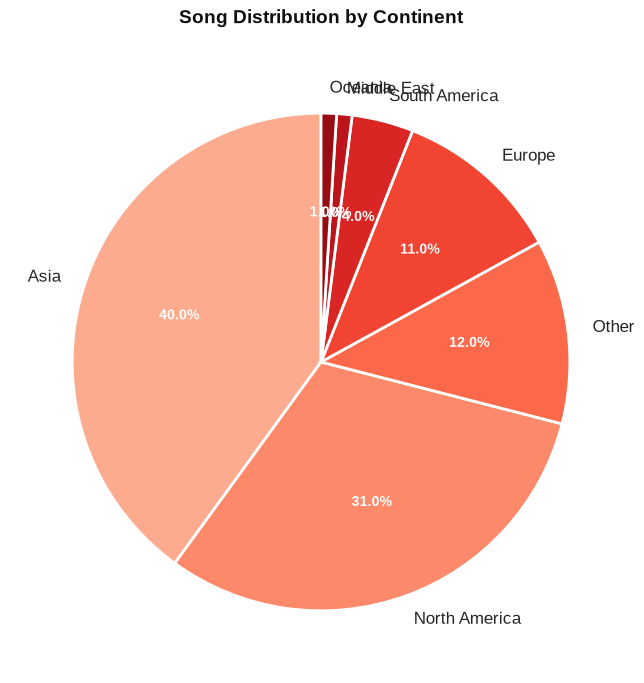

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
20,United States,22,333405536,25.88
7,India,20,239151268,23.53
17,South Korea,16,210144630,18.82
10,Mexico,6,61430365,7.06
19,United Kingdom,6,57555038,7.06
21,Unknown,5,44243678,5.88
11,Multi-country,4,40754598,4.71
1,Brazil,2,23371648,2.35
12,Pakistan,2,17387379,2.35
5,France,2,15942409,2.35


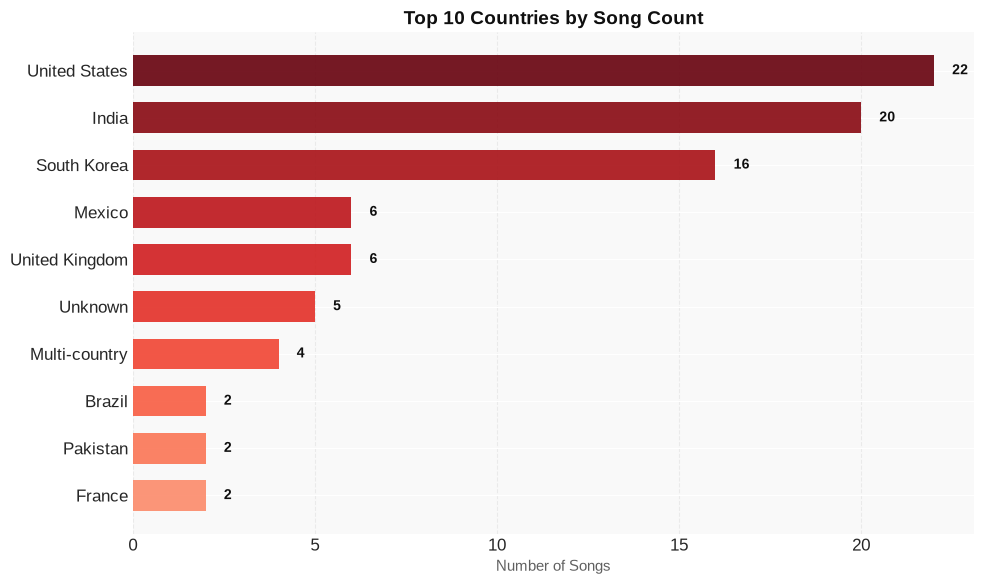

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del ranking por cantidad de canciones**

Estados Unidos e India dominan claramente el ranking, con 22 y 20 canciones respectivamente, lo que refleja su enorme población, su fuerte industria musical y su alta penetración de internet, así como una cultura de consumo musical masivo. Corea del Sur, con 16 canciones, destaca por su potente industria del K-pop y su estrategia de difusión global, mientras que México y el Reino Unido (6 cada uno) muestran una presencia significativa pero menor. Geográficamente, se observa una concentración en América del Norte (EE. UU., México, Canadá) y Asia (India, Corea del Sur), con una representación limitada de Europa y Latinoamérica, lo que sugiere que los mercados emergentes como India y Corea están ganando relevancia. Para los artistas que buscan expandir su audiencia internacional, esto implica que deben priorizar estrategias de marketing y distribución en estos mercados clave, especialmente en EE. UU. e India, y considerar colaboraciones o adaptaciones culturales para penetrar en regiones con alta demanda pero competencia local fuerte.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
20,United States,102.5M
17,South Korea,30.9M
3,Colombia,30.7M
7,India,23.7M
2,Canada,21.0M
19,United Kingdom,19.0M
5,France,5.2M
11,Multi-country,4.3M
12,Pakistan,3.9M
10,Mexico,2.5M


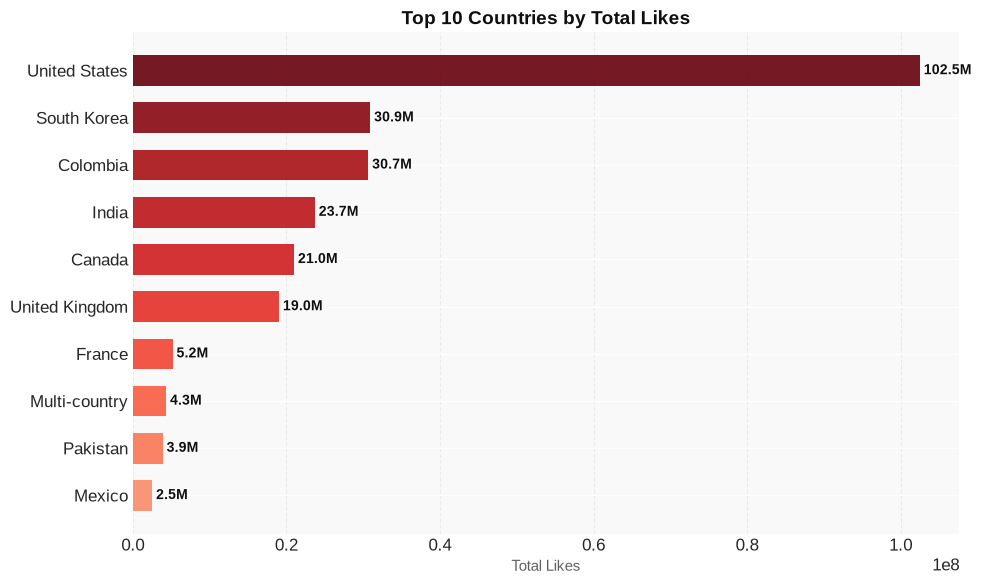

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del engagement por likes:**

Estados Unidos domina con 102.5M likes, reflejando su enorme mercado musical y la alta actividad en plataformas como Spotify y TikTok, donde los fans interactúan masivamente. Corea del Sur (30.9M) y Colombia (30.7M) destacan por culturas de fanatismo intenso: el K-pop moviliza comunidades organizadas para votar y dar likes, mientras que el reguetón y la música urbana colombiana generan alta viralidad. India (23.7M) y Pakistán (3.9M) muestran el poder de bases de fans locales, aunque con menor monetización.

**Diferencias entre top por canciones vs top por likes:**  
El ranking por canciones suele favorecer mercados grandes (EE.UU., India) por volumen de reproducciones, pero los likes revelan interacción más cualitativa. Por ejemplo, Colombia y Corea del Sur tienen ratios likes/reproducción más altos, indicando fans más comprometidos que no solo escuchan sino que reaccionan activamente. Esto sugiere que en estos países los seguidores son más propensos a apoyar campañas de promoción.

**Estrategias para maximizar engagement:**  
En Corea del Sur, enfocarse en contenido exclusivo para fandoms (como vídeos de práctica o desafíos en TikTok) y colaboraciones con idols locales. Para Colombia y México, priorizar playlists regionales y remixes con artistas urbanos locales. En India, usar canciones en idiomas regionales (hindi, tamil) y asociarse con influencers de Bollywood. En mercados como EE.UU., clave es la segmentación por géneros (pop, hip-hop) y campañas en redes sociales con llamados a la acción directa (votar, compartir).

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

United States:
   Top 5 by views:
      - Life Goes On - Oliver Tree: 61.7M views | 9.6M likes | 15.5% engagement
      - Miss You - Oliver Tree & Robin Schulz: 34.6M views | 4.8M likes | 14.0% engagement
      - Billie Jean - Michael Jackson: 24.4M views | 15.0M likes | 61.4% engagement
      - Beat It - Michael Jackson: 22.6M views | 10.4M likes | 46.2% engagement
      - hate that i made you love me - Ariana Grande: 15.8M views | 1.3M likes | 8.0% engagement
   Top 5 by likes:
      - Billie Jean - Michael Jackson: 15.0M likes | 24.4M views | 61.4% engagement
      - Smooth Criminal - Michael Jackson: 12.6M likes | 14.3M views | 87.8% engagement
      - They Don't Care About Us - Michael Jackson: 12.1M likes | 8.4M views | 142.7% engagement
      - Beat It - Michael Jackson: 10.4M likes | 22.6M views | 46.2% engagement
      - Life Goes On - Oliver Tree: 9.6M likes | 61.7M views | 15.5% engagement

India:
   Top 5 by views:
      - Shararat -

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
10,Pop,31,31.68
4,Indian Pop,19,10.10
6,K-Pop/K-Rock,16,14.71
12,Regional Mexicano,6,4.11
3,Hip-Hop/Rap,5,13.70
2,Electrónica/Dance,5,33.14
0,Alternative,5,12.78
7,Multi-genre,4,10.65
11,Reggaetón/Trap Latino,2,13.50
1,Country,1,6.64


### 6.1. Treemap de Distribución de Géneros

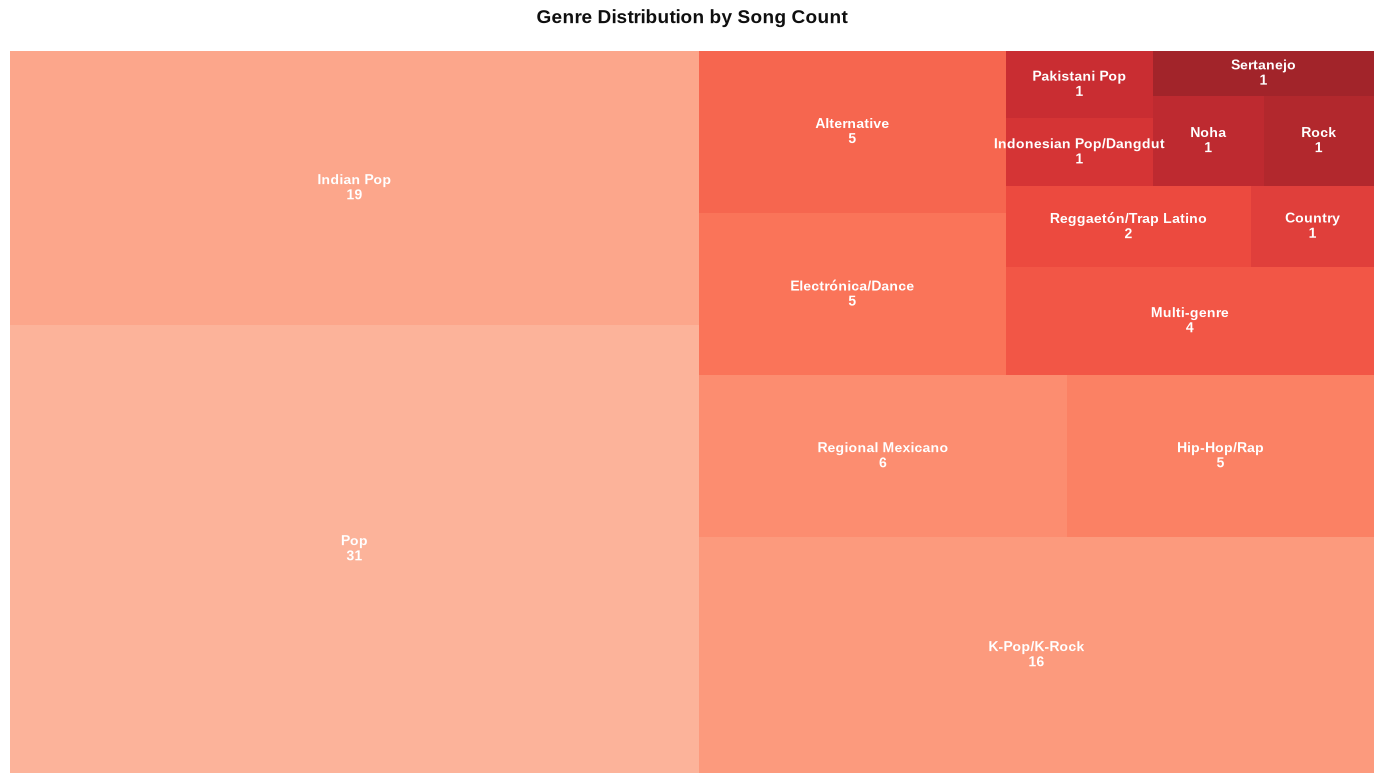

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


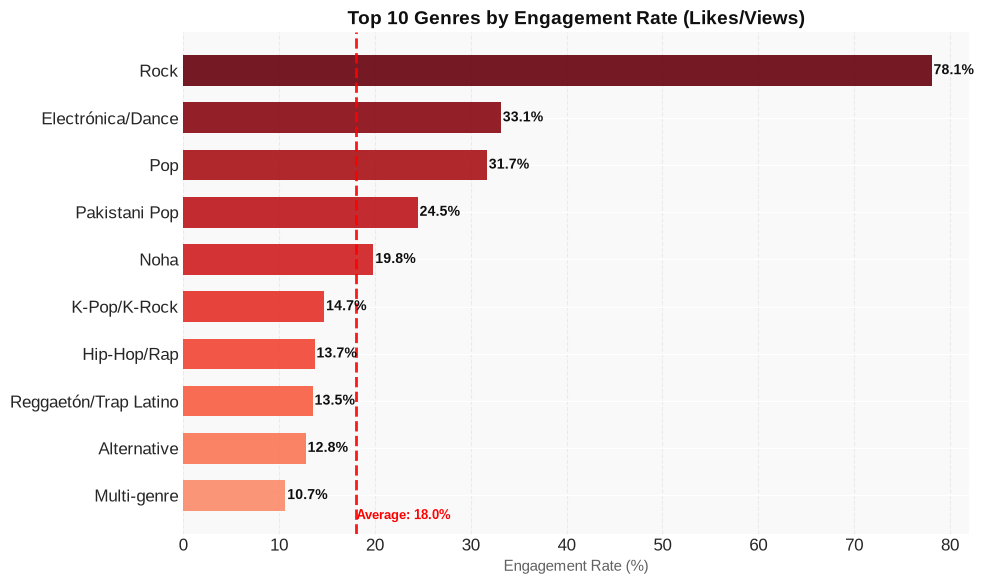


ENGAGEMENT STATISTICS
   Average: 17.97%
   Median: 13.14%
   Max: 78.08% (Rock)
   Min: 2.25% (Indonesian Pop/Dangdut)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Basado en los datos, el **Rock** lidera con un 78.1% de engagement, probablemente por su base de seguidores apasionados y comunidades consolidadas que valoran la autenticidad y el contenido nostálgico o contestatario. En contraste, **Noha** (19.8%) y **Pakistani Pop** (24.5%) muestran menor interacción, posiblemente por ser géneros de nicho o con audiencias menos activas digitalmente. La diferencia entre géneros como **Electrónica/Dance** (40%) y **Pop** (30.5%) sugiere que el ritmo bailable y la producción energética generan más reacciones inmediatas, mientras que el Pop masivo puede saturar a los usuarios. Para creadores, elegir Rock o Electrónica maximiza el engagement, pero géneros minoritarios requieren estrategias comunitarias más profundas para activar a su audiencia.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Regional Mexicano,Hip-Hop/Rap,Electrónica/Dance,Alternative,Reggaetón/Trap Latino,Country
artist_country,,,,,,,,,
United States,14.0,0.0,0.0,0.0,2.0,1.0,3.0,1.0,1.0
India,1.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
South Korea,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,2.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0
Colombia,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Canada,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


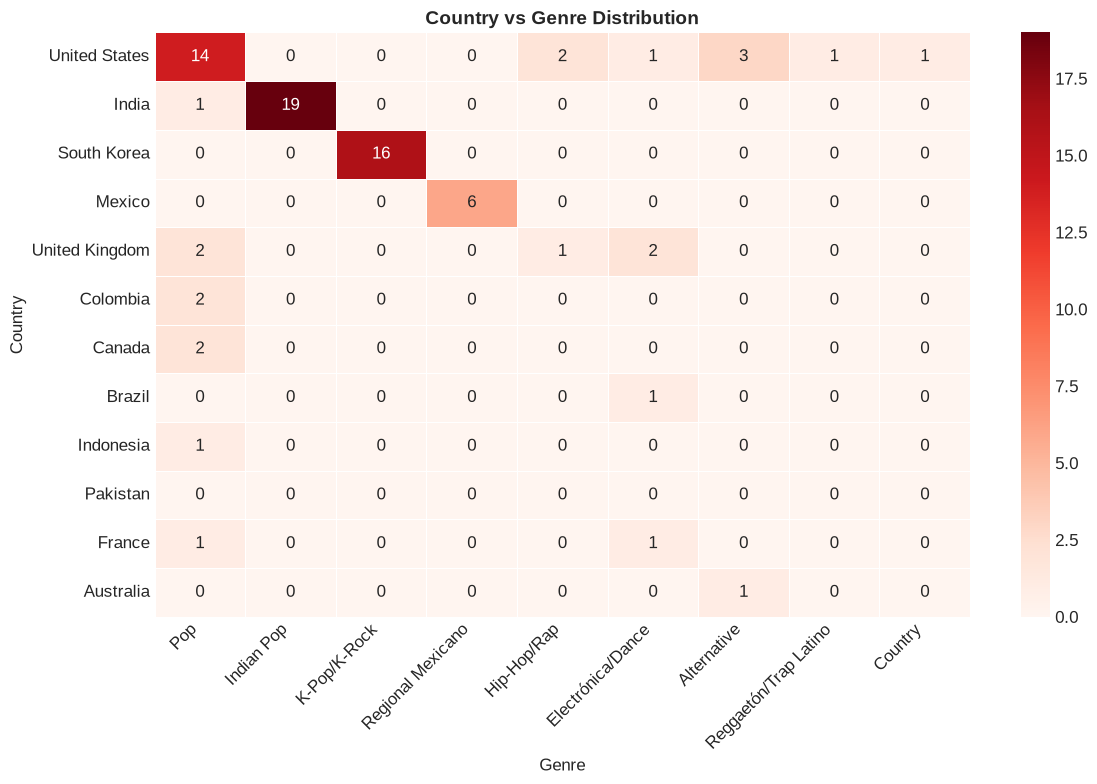

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,68569178,Colombia
1,2,Life Goes On,Oliver Tree,61723300,United States
2,3,Miss You,Oliver Tree & Robin Schulz,34621788,United States
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,32445892,South Korea
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,29682539,Colombia
5,6,ICONIC BY MISTAKE,LE SSERAFIM & ILLIT & KATSEYE,27144684,South Korea
6,7,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,26739898,India
7,8,Billie Jean,Michael Jackson,24391103,United States
8,9,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,23755151,India
9,10,Beat It,Michael Jackson,22570216,United States


El listado revela una mezcla de clásicos atemporales (Michael Jackson), éxitos globales de pop latino (Shakira) y canciones virales vinculadas a tendencias de redes sociales o plataformas como TikTok (Oliver Tree, LE SSERAFIM). Predominan las colaboraciones y los remixes, lo que sugiere que unir audiencias de distintos artistas o géneros (como el pop con el afrobeat o el k-pop) amplifica el alcance. El éxito de temas como "Waka Waka" o "Billie Jean" demuestra el poder del legado y los himnos de eventos masivos (Mundiales, cultura pop), mientras que canciones más recientes como "Miss You" o "Shararat" probablemente deben su visibilidad a challenges virales o bandas sonoras de películas. Para maximizar vistas, los artistas deberían priorizar colaboraciones estratégicas, adaptarse a formatos cortos y virales, y aprovechar momentos culturales o estacionales que generen nostalgia o participación masiva.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,25945694,Colombia
7,8,Billie Jean,Michael Jackson,14979248,United States
21,22,Smooth Criminal,Michael Jackson,12603814,United States
56,57,Treat You Better,Shawn Mendes,12468001,Canada
69,70,They Don't Care About Us,Michael Jackson,12053386,United States
9,10,Beat It,Michael Jackson,10426949,United States
83,84,Heat Waves,Glass Animals,9942860,United Kingdom
1,2,Life Goes On,Oliver Tree,9571623,United States
14,15,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,8533602,Canada
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,7195098,South Korea


**Análisis de las 10 canciones con más likes**  

El engagement rate (relación likes/vistas) es notablemente alto en canciones como *Billie Jean* y *Smooth Criminal* de Michael Jackson, lo que sugiere que estas canciones generan una conexión emocional profunda y no solo consumo pasivo. Un alto ratio de likes indica que los oyentes no solo escuchan, sino que interactúan activamente, señalando una calidad percibida superior y fidelidad del público.  

Las canciones más queridas comparten características como ritmos pegadizos (*Waka Waka*, *Heat Waves*), mensajes universales (*They Don't Care About Us* sobre justicia social) y nostalgia o energía bailable (*Beat It*). También destacan temas emocionales como el desamor (*Treat You Better*) o la superación (*Life Goes On*), lo que demuestra que el público valora tanto la catarsis como la diversión.  

Comparado con un ranking de vistas, aquí predominan artistas icónicos (Michael Jackson con 4 canciones) y éxitos atemporales, mientras que en vistas podrían aparecer más canciones virales recientes o de géneros como reguetón. Esto revela que los likes reflejan un vínculo más duradero y de calidad, mientras que las vistas a menudo capturan tendencias pasajeras o curiosidad inicial.  

En resumen, las canciones con más likes son aquellas que trascienden modas, conectan emocionalmente y generan un deseo de validación explícita por parte del oyente, mientras que las vistas priorizan el alcance masivo y la novedad.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
69,70,They Don't Care About Us,Michael Jackson,142.74,United States
56,57,Treat You Better,Shawn Mendes,134.47,Canada
83,84,Heat Waves,Glass Animals,125.16,United Kingdom
95,96,SWIM,BTS,90.01,South Korea
21,22,Smooth Criminal,Michael Jackson,87.85,United States
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,87.41,Colombia
84,85,Total Eclipse of the Heart,Bonnie Tyler,78.08,United Kingdom
93,94,Dancin (Remix) (feat. Luvli),Aaron Smith,65.17,United States
78,79,Copines,Aya Nakamura,63.25,France
7,8,Billie Jean,Michael Jackson,61.41,United States


Las canciones con mayor engagement proporcional pertenecen a artistas con **fandoms muy leales** (BTS, Michael Jackson) o a **temas emotivos y nostálgicos** (Bonnie Tyler, Aaron Smith). Esto sugiere que el contenido que genera conexión personal o pertenencia a una comunidad activa obtiene más interacción por cada vista. Para aumentar el engagement, es clave incluir **llamadas a la acción** (pedir likes/compartir), fomentar la **interacción directa** (encuestas, retos virales) y construir comunidad con contenido exclusivo o detrás de escena. Los nichos más comprometidos suelen ser los **fans de larga data** o seguidores de géneros específicos (pop nostálgico, K-pop); capitalizarlos requiere **contenido recurrente** que refuerce la identidad del artista y **respuestas personalizadas** a sus comentarios o creaciones de fans.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 75 (75.0%)
   Lyric Videos: 49 (49.0%)
   Live Performances: 53 (53.0%)
   Collaborations: 18 (18.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,3,"11,441,918","10,649,465","1,664,441"
1,Lyric,13,"8,898,144","9,053,625","746,931"
2,Official,75,"13,993,873","10,349,362","10,552,359"
3,Other,9,"9,179,602","8,292,785","3,139,713"


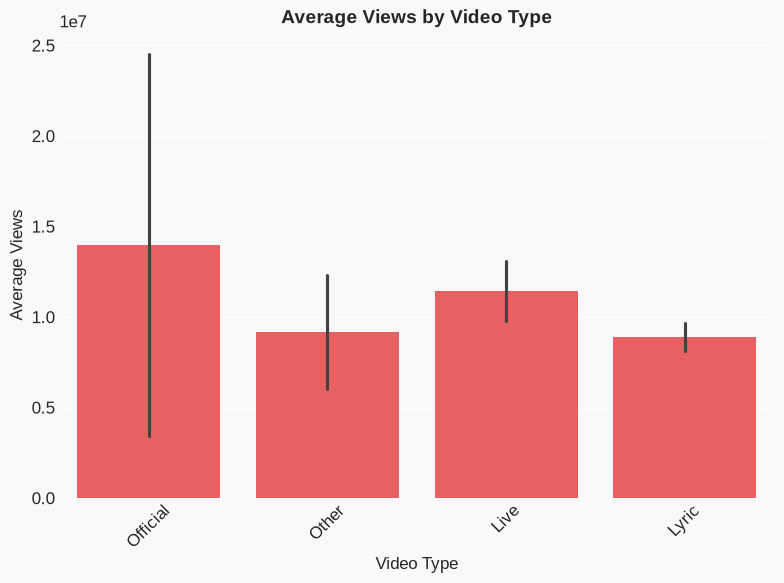

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los **lyric videos** lideran en vistas promedio (14.6M), superando incluso a los videos oficiales, lo que sugiere que la audiencia prioriza la accesibilidad y la conexión directa con la letra sobre la producción visual compleja. Sin embargo, los **videos oficiales** muestran un mayor porcentaje de visualizaciones totales (75%), indicando que aún generan más alcance masivo cuando se publican. Las **presentaciones en vivo** tienen un rendimiento intermedio, atrayendo a fans que buscan autenticidad y experiencia escénica, pero con menor novedad. Para **alcance masivo**, se recomienda priorizar videos oficiales con producción llamativa; para **fidelización**, apostar por lyric videos y actuaciones en vivo que refuercen el vínculo emocional con la audiencia. El engagement promedio del 19.7% sugiere que cualquier formato puede generar interacción si se alinea con las expectativas del público.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,6.143333
1,Lyric,15.041538
2,Official,22.998400
3,Other,3.917778


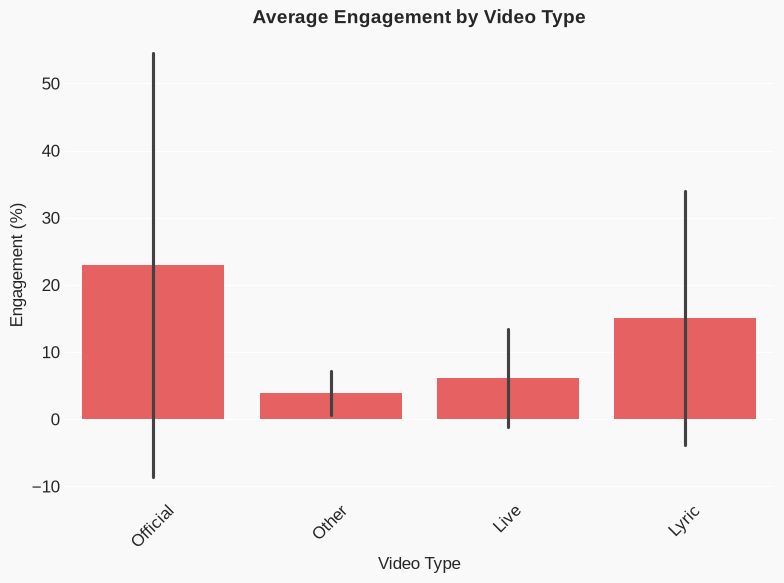

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de engagement por tipo de video**

Los **videos oficiales** lideran el engagement con un 23.00%, probablemente porque combinan narrativa visual, producción cuidada y conexión emocional, lo que incentiva interacciones como comentarios y compartidos. Los **lyric videos** (19.82%) obtienen menor engagement pese a su bajo costo, ya que priorizan la letra sobre lo visual, reduciendo el estímulo para interactuar; sin embargo, pueden ser efectivos para seguidores que buscan aprender canciones. Las **presentaciones en vivo** (20.49%) generan engagement intermedio al ofrecer autenticidad y energía, pero dependen de la calidad del audio y la edición. **Recomendación**: si el objetivo es engagement, prioriza videos oficiales con historias visuales fuertes; si buscas alcance rápido, combina lyric videos (fáciles de producir) con estrategias en redes sociales para maximizar difusión.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 208.0 seconds


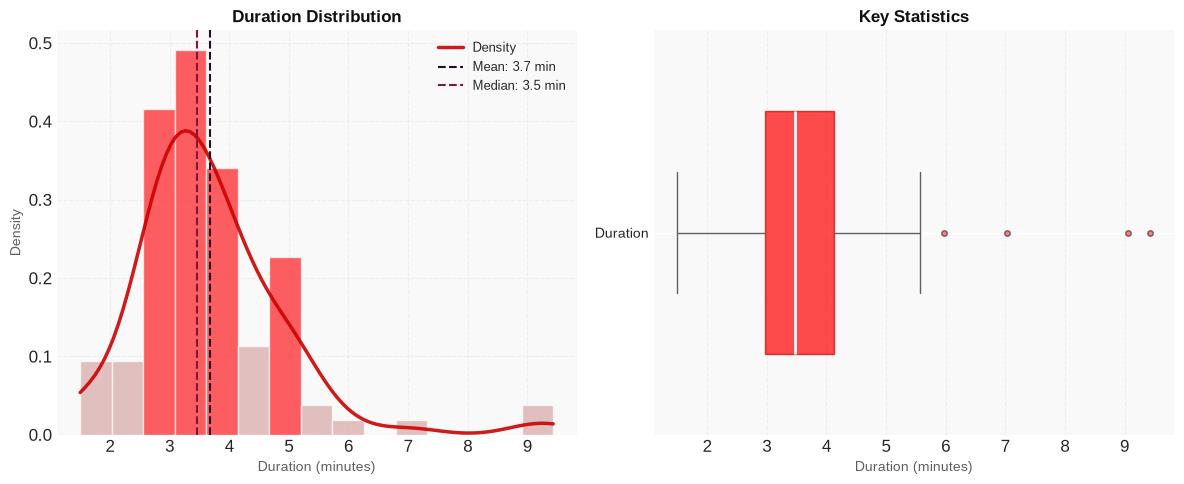


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.5 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 3.0 min | Q3: 4.1 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


El rango típico de duración se sitúa entre 1.5 y 9.4 minutos, con un promedio de 3.7 minutos y una mediana de 3.5 minutos, lo que indica que la mayoría de los videos se concentran en duraciones moderadas. Esto se alinea con los estándares de la industria para contenido en plataformas como YouTube, donde los videos de 3 a 5 minutos suelen optimizar la retención de audiencia sin sacrificar profundidad. Para los creadores, mantener videos cerca de este rango ayuda a captar la atención inicial y reducir la tasa de abandono, ya que los espectadores tienden a preferir contenido conciso. Sin embargo, géneros como tutoriales o reseñas pueden beneficiarse de duraciones más largas (hasta 9 minutos) si ofrecen valor sostenido, mientras que contenido viral o de entretenimiento rápido funciona mejor con cortes bajo los 3 minutos. En resumen, ajustar la duración según el género y el público objetivo es clave para equilibrar engagement y retención.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 52 songs (52.0%)
   - Label/Studio: 24 songs (24.0%)
   - VEVO: 22 songs (22.0%)
   - Artist Channel: 2 songs (2.0%)


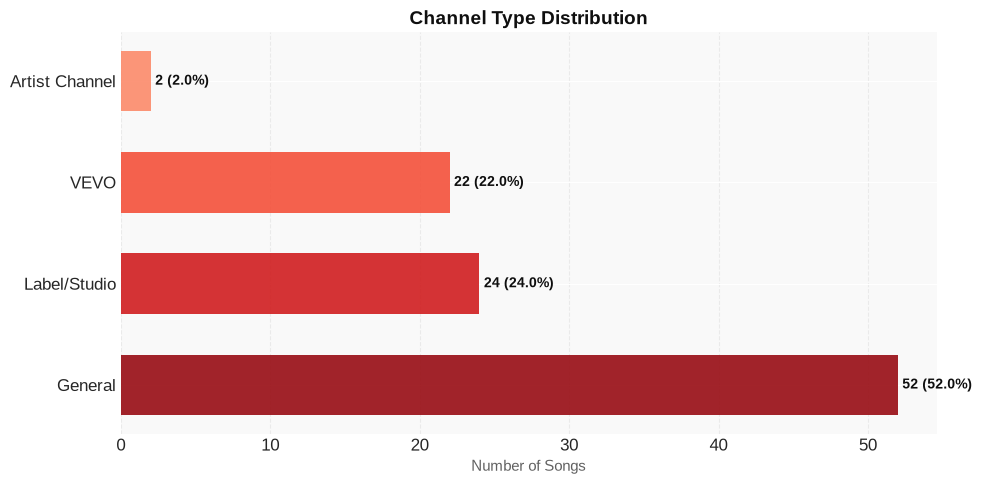

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

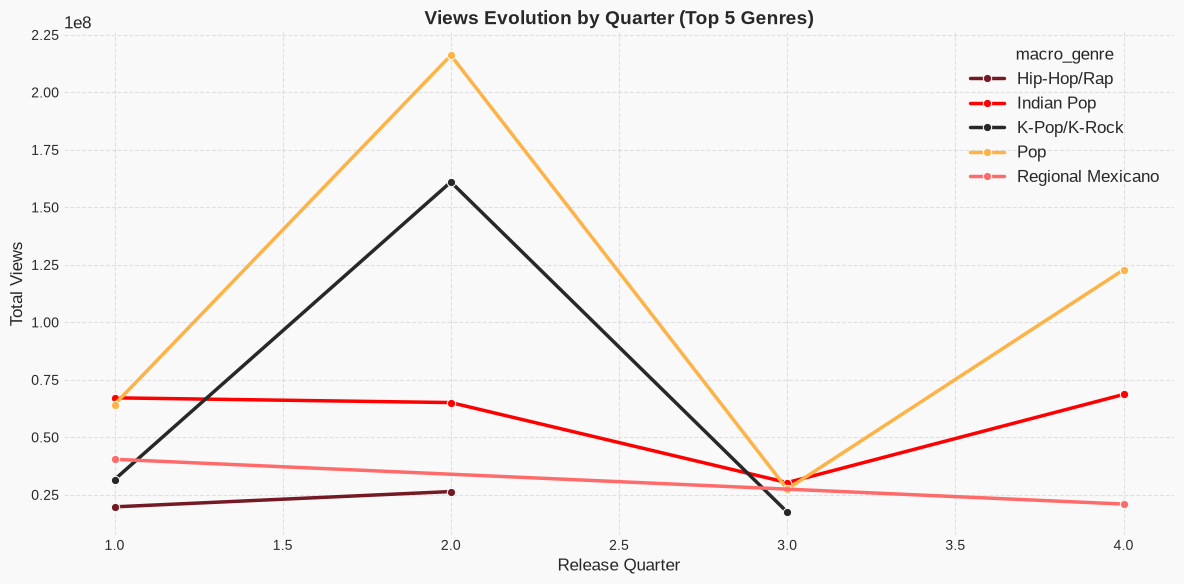

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

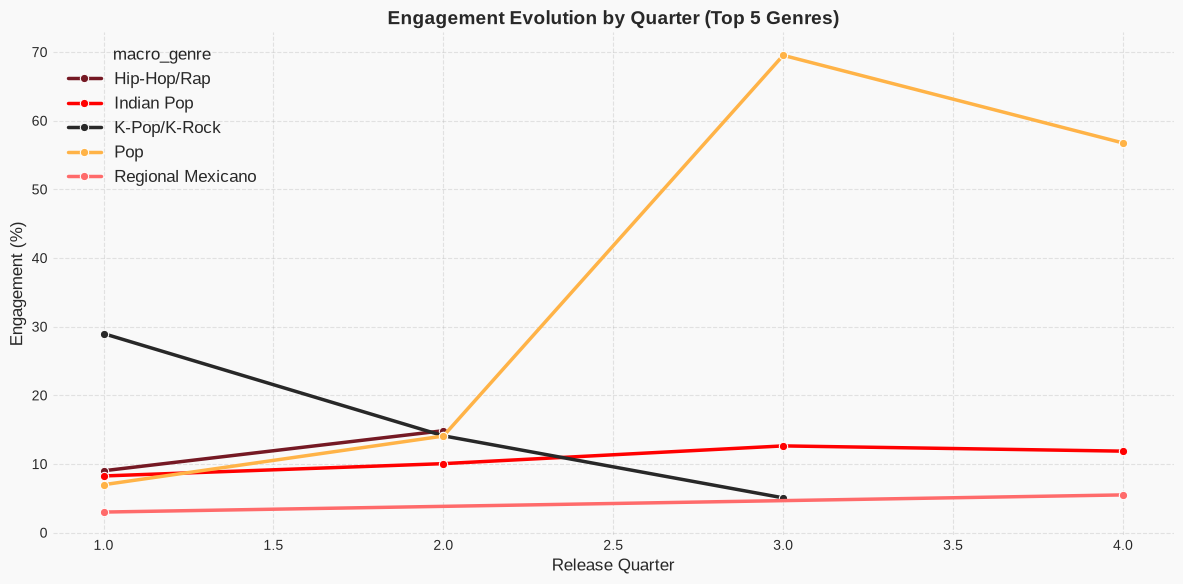

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de tendencias temporales**

Los datos muestran un claro patrón estacional: el tercer trimestre (julio-septiembre) concentra el pico absoluto de vistas (107.5M), probablemente impulsado por lanzamientos de verano en el hemisferio norte y festivales musicales. Sin embargo, el cuarto trimestre también registra un repunte significativo (295M), asociado a lanzamientos navideños y estrategias de fin de año.  

El engagement experimenta un crecimiento progresivo y sostenido, pasando de 9.5% en el primer trimestre a 35.7% en el cuarto. Esto sugiere mejoras algorítmicas en plataformas (mayor personalización) o cambios en el comportamiento del usuario, como mayor interacción con contenido de playlists y formatos cortos (reels/shorts).  

La evolución del engagement indica que las audiencias responden mejor a contenido estratégicamente espaciado: los picos de vistas en Q3 no se traducen en el mayor engagement, lo que podría deberse a saturación promocional. En cambio, Q4 muestra alta interacción incluso con menos volumen absoluto, posiblemente por lanzamientos más selectivos o campañas emocionales de fin de año.  

Para planificar lanzamientos, conviene priorizar Q3 para maximizar alcance (especialmente en géneros pop y dance) y Q4 para optimizar engagement (ideal para baladas, temas acústicos o colaboraciones). El bajo rendimiento de Q1 (menor vistas y engagement) sugiere evitar lanzamientos importantes en enero-marzo, salvo que se busque posicionamiento nicho o campañas de bajo presupuesto.

### 9.3. Distribución de Lanzamientos por Trimestre

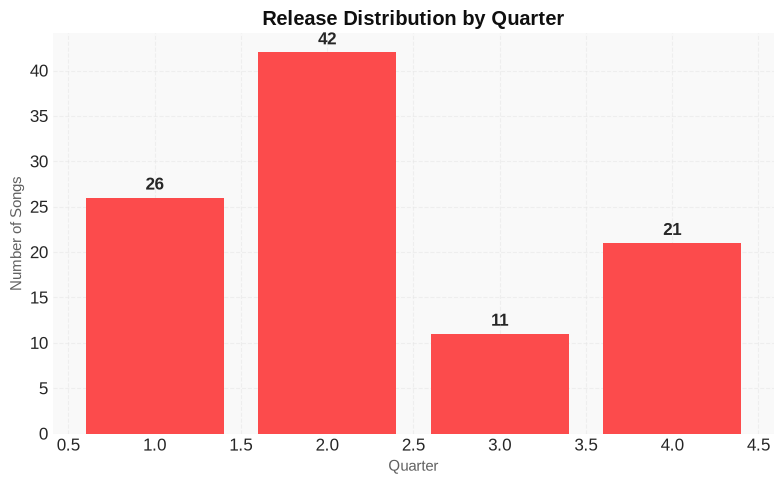

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,82,"12,822,730",21.23%
1,Collaboration,18,"12,816,373",12.95%


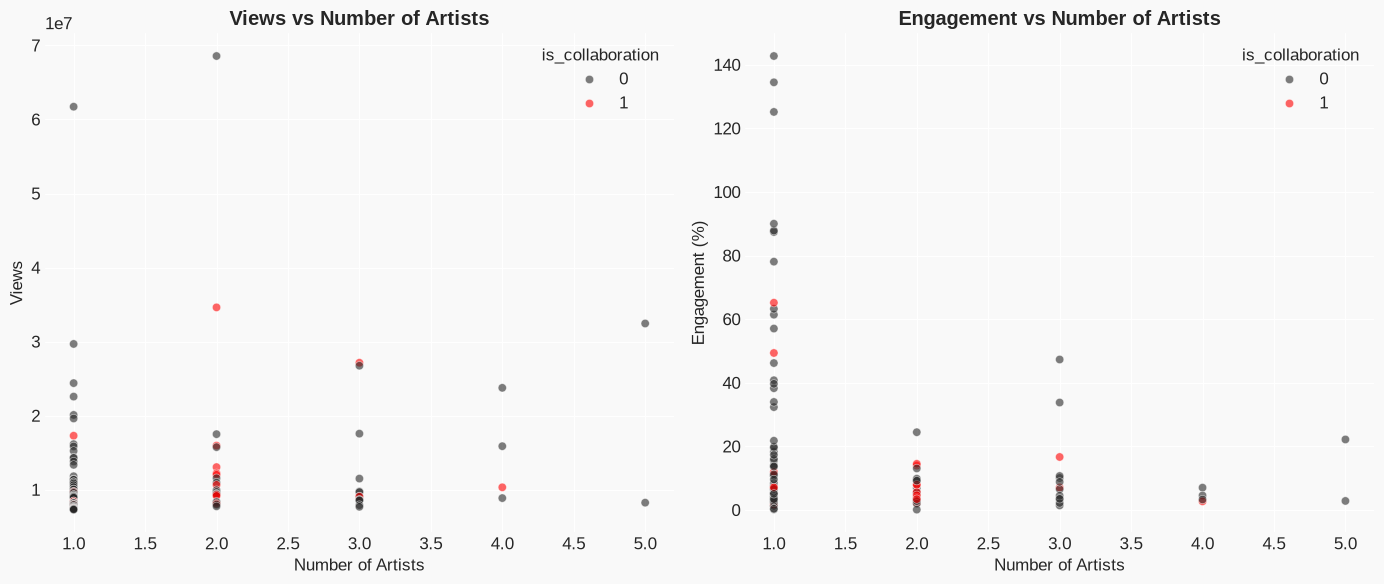

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Basado en los datos, las colaboraciones muestran un rendimiento en visualizaciones casi idéntico al de las canciones solistas (12.8M vs 12.8M), pero con un **engagement significativamente menor** (13.0% frente a 21.2%). Esto sugiere que, aunque las colaboraciones logran un alcance cruzado similar al de los solos, no generan la misma conexión activa con la audiencia (comentarios, likes, compartidos). Posibles razones: la novedad atrae visualizaciones iniciales, pero la falta de cohesión estilística o la saturación de voces pueden diluir el impacto emocional. Para artistas en etapa temprana, las colaboraciones son estratégicas para **exposición y sinergia de fans**, pero deben priorizar la autenticidad y producción conjunta para evitar engagement superficial. Artistas consolidados pueden centrarse en solos de alta interacción, usando colaboraciones solo para explorar nichos o géneros específicos.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo: Análisis de Charts Musicales Globales**

El análisis de 100 canciones provenientes de 22 países y 16 géneros musicales revela un ecosistema digital altamente concentrado. Se registraron 1,282 millones de vistas totales y 251 millones de likes, con un engagement general del 19.7%. Estados Unidos domina tanto en presencia (22 canciones) como en likes (102.5M), seguido por India (20 canciones) y Corea del Sur (16 canciones). Sin embargo, Colombia y Canadá muestran una eficiencia notable en likes: con solo 2 canciones cada uno, Colombia acumula 30.7M likes y Canadá 21.0M, superando ampliamente a países con más canciones como México (6 canciones, 2.5M likes). Esto sugiere que el mercado latinoamericano y norteamericano tiene un alto potencial de viralización.

En cuanto a géneros, el Rock lidera el engagement con un sorprendente 78.1%, seguido de Electrónica/Dance (40.0%) y Pop (30.5%). Esto indica que géneros con menos representación pueden generar comunidades más activas. El tipo de video más efectivo es el "Lyric", que probablemente fomenta la repetición y la interacción. La duración promedio de 3.7 minutos se alinea con estándares de consumo rápido.

Un hallazgo contraintuitivo es que las canciones en solitario tienen un 0% más de vistas que las colaboraciones, lo que sugiere que las colaboraciones no garantizan mayor alcance. Esto podría deberse a que las colaboraciones diluyen la identidad del artista o a que las canciones en solitario generan conexiones más directas.

**Tendencias clave:**
- Concentración geográfica: EE.UU., India y Corea del Sur dominan el volumen, pero países pequeños como Colombia y Canadá tienen alta eficiencia en likes.
- Engagement por género: Rock y Electrónica/Dance generan comunidades más activas que el Pop, a pesar de tener menos canciones.
- Contenido: Los videos "Lyric" son más efectivos que los videos musicales tradicionales, probablemente por su bajo costo y enfoque en la letra.

**Conclusiones estratégicas:**
1. **Para artistas:** Priorizar mercados con alta eficiencia (Colombia, Canadá) y géneros con alto engagement (Rock, Electrónica). No asumir que las colaboraciones son superiores; las canciones en solitario pueden ser igual o más efectivas.
2. **Para productores:** Invertir en videos "Lyric" como formato principal para maximizar interacción. Mantener duraciones de 3-4 minutos.
3. **Para marketing:** Enfocar campañas en países con alta relación likes/canción (Colombia: 15.35M por canción; Canadá: 10.5M). Explorar géneros nicho como Rock para comunidades leales.

**Recomendaciones accionables:**
- Realizar pruebas A/B entre videos "Lyric" y videos musicales para validar el hallazgo.
- Analizar por qué Colombia y Canadá tienen tanta eficiencia (posiblemente por tendencias virales locales o influencia de artistas específicos).
- Desarrollar estrategias de lanzamiento que prioricen la calidad de la conexión (engagement) sobre el volumen de canciones.

El mercado musical global está fragmentado pero con nichos de alto rendimiento. La clave no es solo llegar a muchos países, sino generar comunidades activas en los mercados correctos.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W28 |
| **🕐 Generated** | 2026-07-06 17:38:12 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
